# 1. Imports and Setup.

In [177]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings(
    'ignore',
    message=r"datetime\.datetime\.utcnow",
    category=DeprecationWarning
)

In [178]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings(
    'ignore',
    message=r"datetime\.datetime\.utcnow",
    category=DeprecationWarning
)

# Clustering & dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import LocalOutlierFactor
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# Association rules
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Plot style
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

print('All packages imported successfully')

All packages imported successfully


In [179]:
## Paste Copied Instruction Here If Using Google CoLab, Otherwise Ignore.


# 2. Data Loading.

This section loads the Online Retail dataset and confirms the structure of the raw table before any filtering.

Initial checks:
- total number of rows and columns,
- preview of the first records,
- confirmation of key fields such as invoice number, product description, quantity, unit price, customer ID, and country.

In [180]:
from ucimlrepo import fetch_ucirepo

online_retail = fetch_ucirepo(id=352)
df = online_retail.data.original
print(f'Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head()

Raw dataset: 541,909 rows, 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# 3. Visualizing Raw Data.

Before cleaning the data, inspect the `Quantity` column to understand its spread and detect unusual values.

This first pass helps answer:
- whether the column has missing entries,
- whether most purchases are small,
- whether large positive or negative values appear in the raw transactions.

In [181]:
#summary of the quantity attribute.
# notes: this shows that there no missing quantity input as the count of quantity instances matches the total number of rows in the data.
df["Quantity"].describe()

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

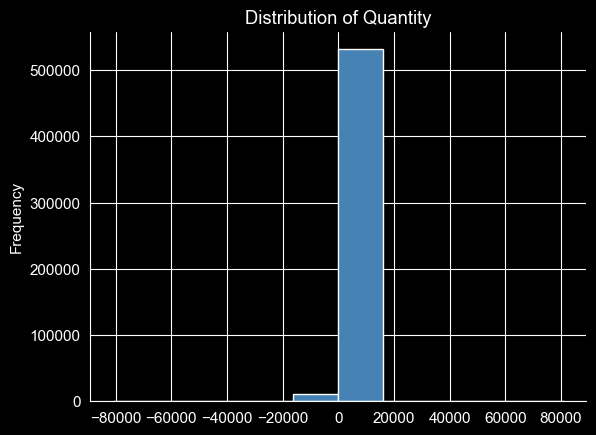

In [182]:
df["Quantity"].plot.hist(bins=10,color = 'steelblue').set_title("Distribution of Quantity")
plt.show()

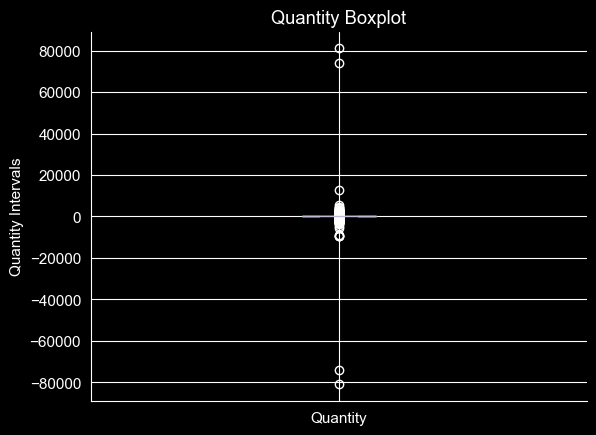

In [183]:
ax = df.boxplot(column="Quantity")
ax.set_ylabel("Quantity Intervals")
ax.set_title("Quantity Boxplot")
plt.show()

In [184]:
#summary of the unit price attribute.
# notes: from the description presented it can be seen that there is a negative unit price. for a dataset which focuses on sales, negative values should be discarded as they do not account for actual sales.
df["UnitPrice"].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

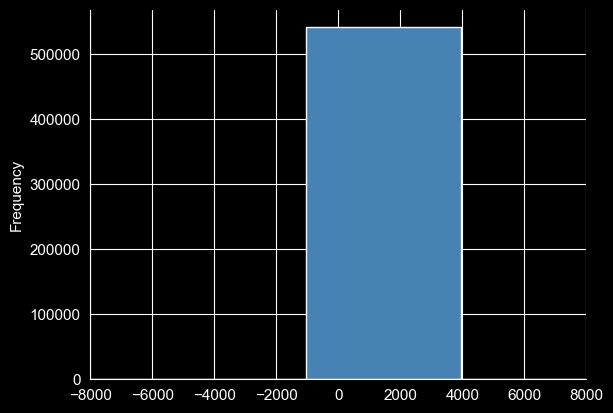

In [185]:
df["UnitPrice"].plot.hist(bins=10, color = 'steelblue')
plt.xlim(-8000,8000)
plt.show()



#notes: it can be seen that for the unit price some values lie to the left of the origin indicating that there are some refunds.

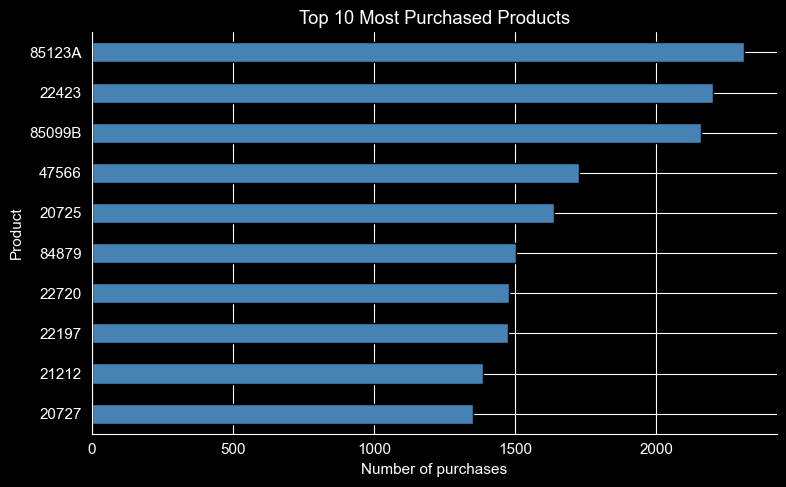

In [186]:
# Top 10 by number of rows (purchases)
top10 = df["StockCode"].value_counts().head(10)

ah = top10.plot(
    kind="barh",
    figsize=(8, 5),
    color="steelblue",
    edgecolor="black"
)

ah.invert_yaxis()           # highest at top
ah.set_xlabel("Number of purchases")
ah.set_ylabel("Product")
ah.set_title("Top 10 Most Purchased Products")

plt.tight_layout()
plt.show()

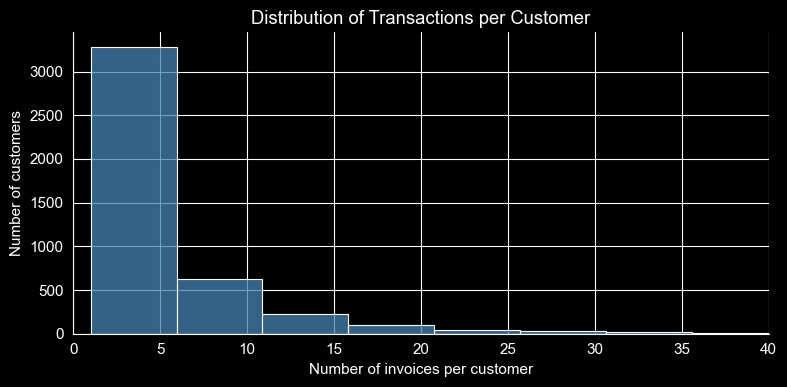

In [187]:
# rows with a valid customerID
cust_transaction = df.dropna(subset=['CustomerID'])

# One transaction = one unique invoice for that customer
transaction_per_cust = (cust_transaction[['CustomerID', 'InvoiceNo']]
               .drop_duplicates()
               .groupby('CustomerID')['InvoiceNo']
               .count()
               .rename('num_invoices'))

#chekcing the customer transactions.
transaction_per_cust.head()
#plotting the distribution of invoices per customer.
plt.figure(figsize=(8,4))
sns.histplot(transaction_per_cust, bins=50, kde=False, color='steelblue')
plt.xlabel('Number of invoices per customer')
plt.ylabel('Number of customers')
plt.title('Distribution of Transactions per Customer')

plt.xlim(0,40) #limiting the range of the x-axis to at most 40 invoices.
plt.tight_layout()
plt.show()

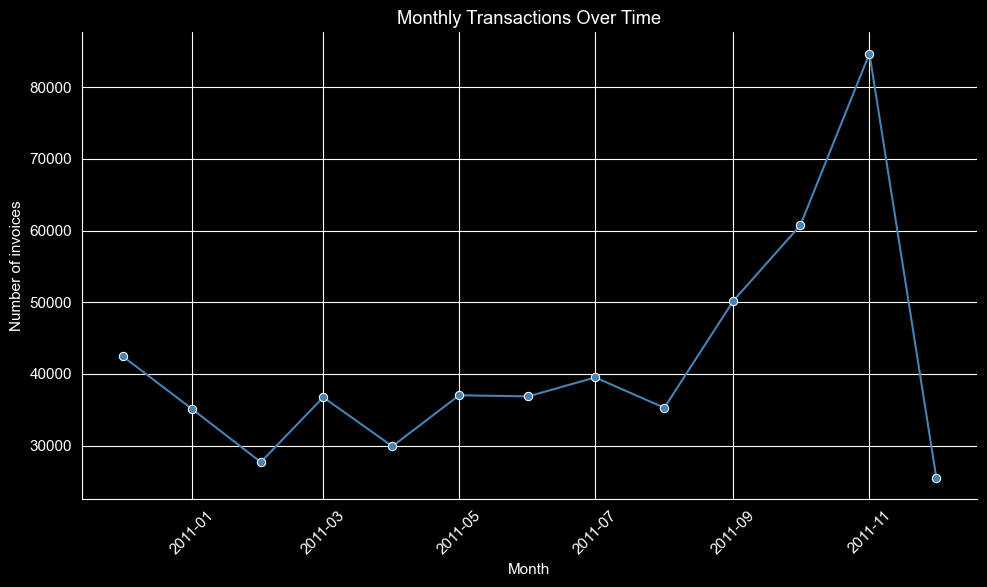

In [188]:
#since invoice date and time is stored as a string, first convert that to the datatime datatype.
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
transaction_per_month = (df[['InvoiceMonth', 'InvoiceNo']].groupby(
    'InvoiceMonth')['InvoiceNo'].count())

transaction_per_month.index = transaction_per_month.index.to_timestamp()

#plotting the monthly transaction counts
plt.figure(figsize=(10,6))
sns.lineplot(x=transaction_per_month.index, y=transaction_per_month.values, marker='o', color = 'steelblue')
plt.xlabel('Month')
plt.ylabel('Number of invoices')
plt.title('Monthly Transactions Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Data Cleaning and Preprocessing.


Retail transaction data includes cancellations, invalid quantities, and missing values that can distort downstream analysis.

The cleaning steps below keep only valid UK purchase records and create a transaction value field (`TotalPrice`) for later customer-level analysis.

In [189]:
# 1. Remove cancellations (InvoiceNo starts with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 2. UK-only
df = df[df['Country'] == 'United Kingdom']

# 3. Positive quantities only
df = df[df['Quantity'] > 0]

# 4. Non-null, non-empty descriptions
df = df[~(df['Description'].isna() | (df['Description'].str.strip() == ''))]

# 5. Positive unit prices only
df = df[df['UnitPrice'] > 0]

# 6. Parse dates and derived columns
df['InvoiceDate']  = pd.to_datetime(df['InvoiceDate'])
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Month']        = df['InvoiceDate'].dt.month
df['TotalPrice']   = df['Quantity'] * df['UnitPrice']

print(f'Clean dataset: {df.shape[0]:,} rows')
print(f'Date range:    {df["InvoiceDate"].min().date()} — {df["InvoiceDate"].max().date()}')
print(f'Invoices: {df["InvoiceNo"].nunique():,}\n  '
      f'Customers (with ID): {df["CustomerID"].nunique():,}\n  '
      f'Unique products: {df["StockCode"].nunique():,}')

Clean dataset: 485,123 rows
Date range:    2010-12-01 — 2011-12-09
Invoices: 18,019
  Customers (with ID): 3,920
  Unique products: 3,916


# 5. Association Rule Mining — Apriori vs FP-Growth
Both algorithms are run on the same basket matrix with identical thresholds, allowing a direct comparison of runtime and rule output.<br>
**Threshold justification:**
- `min_support = 0.01` (1% of invoices). At 0.02 only 5 rules survived. At 0.01, 177 rules emerged across three distinct product families. At 0.005, >2,000 rules with many trivial patterns.
- `min_confidence = 0.80`: Each rule predicts its consequent in at least 80% of qualifying transactions.

In [190]:
# Build basket matrix (one row per invoice)
baskets = (df.groupby('InvoiceNo')['Description']
             .apply(list)
             .reset_index(name='items'))
transactions = baskets['items'].tolist()

te = TransactionEncoder()
oht = te.fit(transactions).transform(transactions, sparse= True)
# Cast columns to plain str — avoids mlxtend/numpy string-type incompatibility
basket_matrix = pd.DataFrame.sparse.from_spmatrix(oht,
    columns=[str(c) for c in te.columns_]
)
print(f'Basket matrix: {basket_matrix.shape[0]:,} invoices * {basket_matrix.shape[1]:,} products')

Basket matrix: 18,019 invoices * 4,007 products


In [191]:
# Apriori
t0 = time.perf_counter()
fi_apriori = apriori(basket_matrix, min_support=0.01, use_colnames=True, low_memory= True)
ir_apriori = association_rules(fi_apriori, metric='confidence', min_threshold=0.80)
t_apriori  = time.perf_counter() - t0

# FP-Growth
t0 = time.perf_counter()
fi_fp = fpgrowth(basket_matrix, min_support=0.01, use_colnames=True)
ir_fp = association_rules(fi_fp, metric='confidence', min_threshold=0.80)
t_fp  = time.perf_counter() - t0

#  Comparison table
comparison = pd.DataFrame({
    'Algorithm':      ['Apriori', 'FP-Growth'],
    'Frequent itemsets': [len(fi_apriori), len(fi_fp)],
    'Rules generated':   [len(ir_apriori), len(ir_fp)],
    'Runtime (s)':       [round(t_apriori, 3), round(t_fp, 3)],
    'Speedup':           ['1.0*', f'{t_apriori/t_fp:.1f}*'],
})
print('=== Algorithm Comparison ===')
print(comparison.to_string(index=False))
print('Note: RUNTIMES CALCULATED ARE DEVICE RESOURCE DEPENDENT.')

print(f'\nRule sets identical: {len(ir_apriori) == len(ir_fp)}')

=== Algorithm Comparison ===
Algorithm  Frequent itemsets  Rules generated  Runtime (s) Speedup
  Apriori               2156              177        6.553    1.0*
FP-Growth               2156              177        6.827    1.0*
Note: RUNTIMES CALCULATED ARE DEVICE RESOURCE DEPENDENT.

Rule sets identical: True


In [192]:
# Top rules by lift
item_rules = ir_apriori.copy()   # using Apriori output for remainder
item_rules.sort_values('lift', ascending=False)[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].head(10)

,antecedents,consequents,support,confidence,lift
120,frozenset({HERB MARKER THYME}),"frozenset({HERB MARKER ROSEMARY, HERB MARKER P...",0.010933,0.856522,74.558769
115,"frozenset({HERB MARKER ROSEMARY, HERB MARKER P...",frozenset({HERB MARKER THYME}),0.010933,0.951691,74.558769
112,frozenset({HERB MARKER ROSEMARY}),"frozenset({HERB MARKER THYME, HERB MARKER MINT})",0.010600,0.826840,74.494134
111,"frozenset({HERB MARKER THYME, HERB MARKER MINT})",frozenset({HERB MARKER ROSEMARY}),0.010600,0.955000,74.494134
103,"frozenset({HERB MARKER THYME, HERB MARKER MINT})",frozenset({HERB MARKER PARSLEY}),0.010433,0.940000,74.288860
108,frozenset({HERB MARKER PARSLEY}),"frozenset({HERB MARKER THYME, HERB MARKER MINT})",0.010433,0.824561,74.288860
118,frozenset({HERB MARKER ROSEMARY}),"frozenset({HERB MARKER THYME, HERB MARKER PARS...",0.010933,0.852814,74.236004
117,"frozenset({HERB MARKER THYME, HERB MARKER PARS...",frozenset({HERB MARKER ROSEMARY}),0.010933,0.951691,74.236004
94,frozenset({HERB MARKER ROSEMARY}),"frozenset({HERB MARKER THYME, HERB MARKER BASIL})",0.010711,0.835498,74.161751
93,"frozenset({HERB MARKER THYME, HERB MARKER BASIL})",frozenset({HERB MARKER ROSEMARY}),0.010711,0.950739,74.161751


In [193]:
#sorting the itemsets into groups.
def family_from_antecedent(itemset):
    s = " ".join(map(str, itemset)).upper()
    if "HERB" in s:
        return "Herb Markers"
    elif "REGENCY" in s or "TEACUP" in s:
        return "Regency Teacup Set"
    elif "JUMBO" in s:
        return "Jumbo Bag Collection"
    else:
        return "Other"

item_rules['family'] = item_rules['antecedents'].apply(family_from_antecedent)

families = (item_rules
            .groupby('family')
            .agg(Rules=('lift','size'),
                 Avg_Lift=('lift','mean'),
                 Avg_Confidence=('confidence','mean'))
            .reset_index())
print(families.to_string(index=False))

              family  Rules  Avg_Lift  Avg_Confidence
        Herb Markers     81 71.235384        0.878569
Jumbo Bag Collection     36  9.532477        0.836183
               Other     40 21.964182        0.852606
  Regency Teacup Set     20 26.752291        0.876311


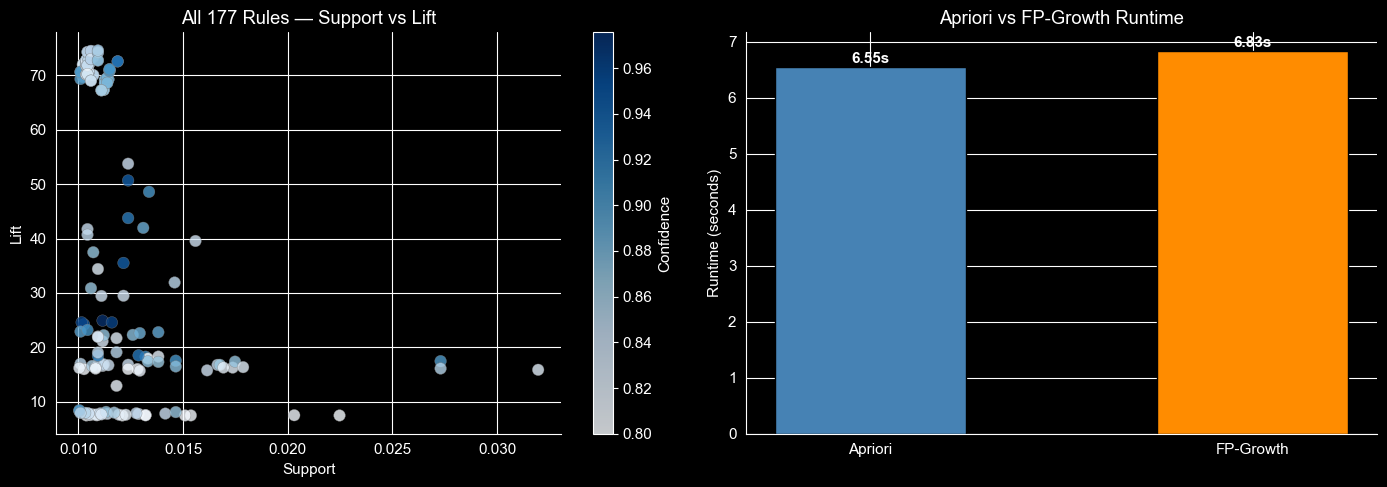

In [194]:
#figures showing findings from running the two algorithms.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Support vs Lift, colored by confidence
sc = axes[0].scatter(item_rules['support'], item_rules['lift'],
                     c=item_rules['confidence'], cmap='Blues',
                     alpha=0.8, edgecolors='grey', linewidths=0.3, s=70)
plt.colorbar(sc, ax=axes[0], label='Confidence')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Lift')
axes[0].set_title(f'All {len(item_rules)} Rules — Support vs Lift')

# Right: Apriori vs FP-Growth runtime bar
axes[1].bar(['Apriori', 'FP-Growth'], [t_apriori, t_fp],
            color=['steelblue', 'darkorange'], edgecolor='black', width=0.5)
axes[1].set_ylabel('Runtime (seconds)')
axes[1].set_title('Apriori vs FP-Growth Runtime')
for i, v in enumerate([t_apriori, t_fp]):
    axes[1].text(i, v + 0.02, f'{v:.2f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [195]:
# Effect of threshold choice; justifying the threshold choice for both algorithms and why a support of 0.02 is impractical.
frequent_itemsets2 = apriori(basket_matrix, min_support=0.02, use_colnames=True)
item_rules2 = association_rules(frequent_itemsets2, metric='confidence', min_threshold=0.80)
print(f'At min_support=0.02: {len(item_rules2)} rules')
print(f'At min_support=0.01: {len(item_rules)} rules')
print('\nAll rules at min_support=0.02:')
item_rules2.sort_values('lift', ascending=False)[
    ['antecedents','consequents','support','confidence','lift']
]

At min_support=0.02: 5 rules
At min_support=0.01: 177 rules

All rules at min_support=0.02:


,antecedents,consequents,support,confidence,lift
1,"frozenset({ROSES REGENCY TEACUP AND SAUCER , P...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.027305,0.902752,17.453534
2,"frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.027305,0.854167,16.099612
0,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.031966,0.820513,15.863541
3,"frozenset({JUMBO BAG PINK POLKADOT, JUMBO SHOP...",frozenset({JUMBO BAG RED RETROSPOT}),0.020312,0.806167,7.507147
4,"frozenset({JUMBO STORAGE BAG SUKI, JUMBO BAG P...",frozenset({JUMBO BAG RED RETROSPOT}),0.022476,0.801980,7.468156


# 6. RFM Feature Engineering
RFM reduces each customer to three interpretable behavioral dimensions:
- **Recency** - days since last purchase (lower = more recent)
- **Frequency** - number of distinct invoices
- **Monetary** - total spend in GBP

Only customers with a valid CustomerID are used for customer-level analysis.


In [196]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Reference date (day after last transaction): {reference_date.date()}')

df_cust = df.dropna(subset=['CustomerID']).copy()
df_cust['CustomerID'] = df_cust['CustomerID'].astype(int)

rfm = df_cust.groupby('CustomerID').agg(
    Recency  = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency= ('InvoiceNo',   'nunique'),
    Monetary = ('TotalPrice',  'sum')
).reset_index()

print(f'Customers with complete RFM: {len(rfm):,}')
rfm.describe().round(2)

Reference date (day after last transaction): 2011-12-10
Customers with complete RFM: 3,920


,CustomerID,Recency,Frequency,Monetary
count,3920.00,3920.00,3920.00,3920.00
mean,15562.06,92.21,4.25,1864.39
std,1576.59,99.53,7.20,7482.82
min,12346.00,1.00,1.00,3.75
25%,14208.75,18.00,1.00,300.28
50%,15569.50,51.00,2.00,652.28
75%,16913.25,143.00,5.00,1576.58
max,18287.00,374.00,209.00,259657.30


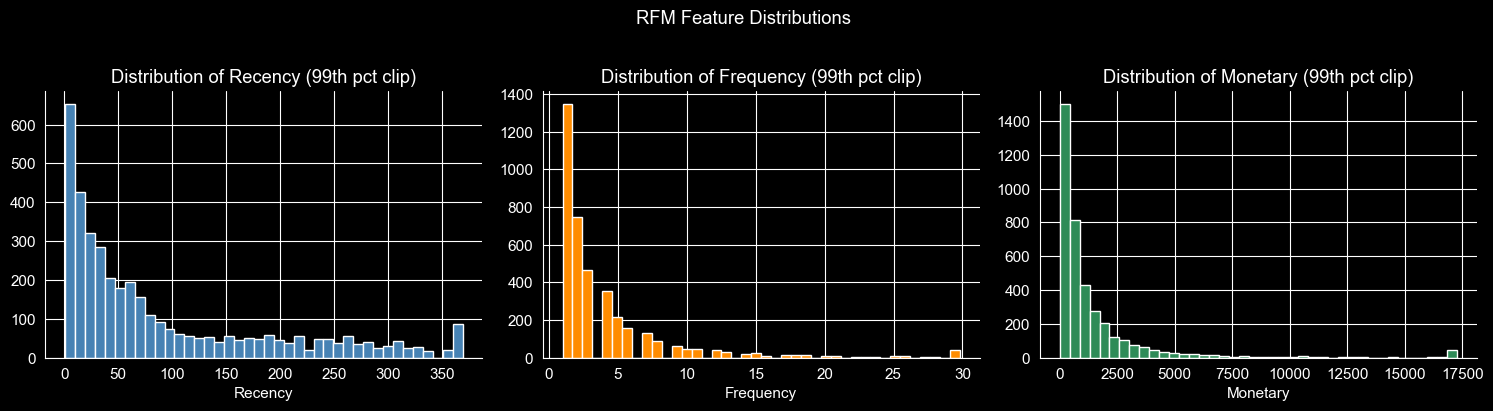

In [197]:
#figures displaying the distribution of RFM features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes,
    ['Recency','Frequency','Monetary'],
    ['steelblue','darkorange','seagreen']):
    rfm[col].clip(upper=rfm[col].quantile(0.99)).hist(bins=40, color=color, ax=ax)
    ax.set_title(f'Distribution of {col} (99th pct clip)')
    ax.set_xlabel(col)
plt.suptitle('RFM Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

In [198]:
# Standardizing RFM features.
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])
print('StandardScaler applied — mean ~0, std ~1 per feature')
pd.DataFrame(rfm_scaled, columns=['R_scaled','F_scaled','M_scaled']).describe().round(3)

StandardScaler applied — mean ~0, std ~1 per feature


,R_scaled,F_scaled,M_scaled
count,3920.000,3920.000,3920.000
mean,-0.000,0.000,0.000
std,1.000,1.000,1.000
min,-0.916,-0.451,-0.249
25%,-0.746,-0.451,-0.209
50%,-0.414,-0.312,-0.162
75%,0.510,0.105,-0.038
max,2.831,28.445,34.456


# 7. Clustering - K-Means vs Hierarchical

Both algorithms are run at k=4 on standardised RFM features.
Three validation metrics are reported: **Silhouette** (higher = better separation),
**Davies-Bouldin** (lower = better), and **Calinski-Harabasz** (higher = better).



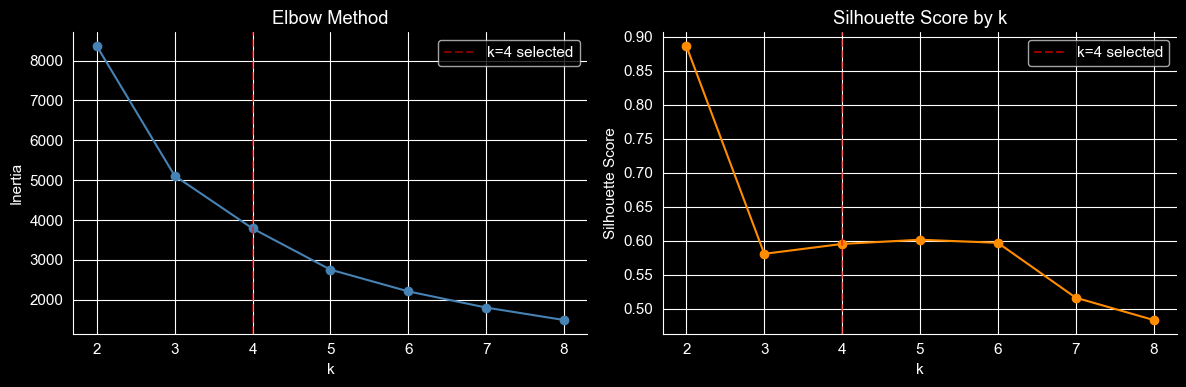

Best k by silhouette: 2  (score=0.886)


In [199]:
inertias, silhouettes = [], []
K_range = range(2, 9)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, 'o-', color='steelblue')
axes[0].axvline(x=4, ls='--', color='red', alpha=0.5, label='k=4 selected')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method'); axes[0].legend()

axes[1].plot(list(K_range), silhouettes, 'o-', color='darkorange')
axes[1].axvline(x=4, ls='--', color='red', alpha=0.6, label='k=4 selected')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f'Best k by silhouette: {list(K_range)[silhouettes.index(max(silhouettes))]}  '
      f'(score={max(silhouettes):.3f})')

In [200]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = km_final.fit_predict(rfm_scaled)

sil_km = silhouette_score(rfm_scaled, rfm['KMeans_Cluster'])
db_km  = davies_bouldin_score(rfm_scaled, rfm['KMeans_Cluster'])
ch_km  = calinski_harabasz_score(rfm_scaled, rfm['KMeans_Cluster'])

cluster_profile = rfm.groupby('KMeans_Cluster').agg(
    Count         = ('CustomerID','count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean'),
    Total_Revenue = ('Monetary',  'sum')
).round(1)
cluster_profile['Revenue_%'] = (cluster_profile['Total_Revenue'] /
                                  cluster_profile['Total_Revenue'].sum() * 100).round(1)

print(f'K-Means (k=4) -- Silhouette: {sil_km:.3f} ; Davies-Bouldin: {db_km:.3f} ; Calinski-Harabasz: {ch_km:.0f}')
cluster_profile

K-Means (k=4) -- Silhouette: 0.595 ; Davies-Bouldin: 0.619 ; Calinski-Harabasz: 2745


,Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_%
KMeans_Cluster,,,,,,
0,989,244.6,1.6,526.7,520941.3,7.1
1,52,12.2,43.8,31172.2,1620955.4,22.2
2,2876,41.4,4.4,1579.9,4543814.4,62.2
3,3,3.3,36.0,207560.2,622680.6,8.5


In [201]:
# Assigning business labels to the K-Means centroids based on RFM values
profile = rfm.groupby('KMeans_Cluster').agg(
    R=('Recency', 'mean'), F=('Frequency', 'mean'), M=('Monetary', 'mean'))

names = {profile['M'].idxmax(): 'Champions'}
remaining = [c for c in profile.index if c not in names]
names[profile.loc[remaining, 'F'].idxmax()] = 'Loyal Regulars'
remaining = [c for c in profile.index if c not in names]
names[profile.loc[remaining, 'R'].idxmax()] = 'At-Risk / Lapsed'
remaining = [c for c in profile.index if c not in names]
names[remaining[0]] = 'New / Occasional'

rfm['Segment'] = rfm['KMeans_Cluster'].map(names)
print('Segment sizes:')
print(rfm['Segment'].value_counts())

Segment sizes:
Segment
New / Occasional    2876
At-Risk / Lapsed     989
Loyal Regulars        52
Champions              3
Name: count, dtype: int64


In [202]:
# Champions cluster — stability & k-sensitivity analysis

# 1. Seed stability - run K-Means five times and then record Champions size each time
seeds = [0, 7, 13, 42, 99]
stability_rows = []
for seed in seeds:
    km_s = KMeans(n_clusters=4, random_state=seed, n_init=10)
    labels_s = km_s.fit_predict(rfm_scaled)
    sil_s = silhouette_score(rfm_scaled, labels_s)
    # Identify which cluster has the highest avg Monetary
    tmp = rfm[['Monetary']].copy()
    tmp['lbl'] = labels_s
    champ_cluster = tmp.groupby('lbl')['Monetary'].mean().idxmax()
    champ_size = (labels_s == champ_cluster).sum()
    stability_rows.append({'Seed': seed, 'Champions_n': champ_size,
                           'Champions_%': round(champ_size / len(labels_s) * 100, 2),
                           'Silhouette': round(sil_s, 3)})

stability_df = pd.DataFrame(stability_rows)
print('=== K-Means Stability Across 5 Random Seeds (k=4) ===')
print(stability_df.to_string(index=False))
print()

# 2. k-sensitivity — compare k=3,4,5 on segment balance and silhouette
k_rows = []
for k in [3, 4, 5]:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km_k.fit_predict(rfm_scaled)
    sil_k = silhouette_score(rfm_scaled, labels_k)
    sizes = pd.Series(labels_k).value_counts().sort_index()
    min_size = sizes.min()
    max_size = sizes.max()
    k_rows.append({'k': k, 'Silhouette': round(sil_k, 3),
                   'Min_cluster_size': min_size, 'Max_cluster_size': max_size,
                   'Size_ratio (max/min)': round(max_size / min_size, 1)})

k_df = pd.DataFrame(k_rows)
print('=== k-Sensitivity: Silhouette and Cluster Balance ===')
print(k_df.to_string(index=False))
print()

=== K-Means Stability Across 5 Random Seeds (k=4) ===
 Seed  Champions_n  Champions_%  Silhouette
    0            3         0.08       0.595
    7            3         0.08       0.595
   13            3         0.08       0.595
   42            3         0.08       0.595
   99            3         0.08       0.595

=== k-Sensitivity: Silhouette and Cluster Balance ===
 k  Silhouette  Min_cluster_size  Max_cluster_size  Size_ratio (max/min)
 3       0.581                23              2901                 126.1
 4       0.595                 3              2876                 958.7
 5       0.601                 3              2646                 882.0



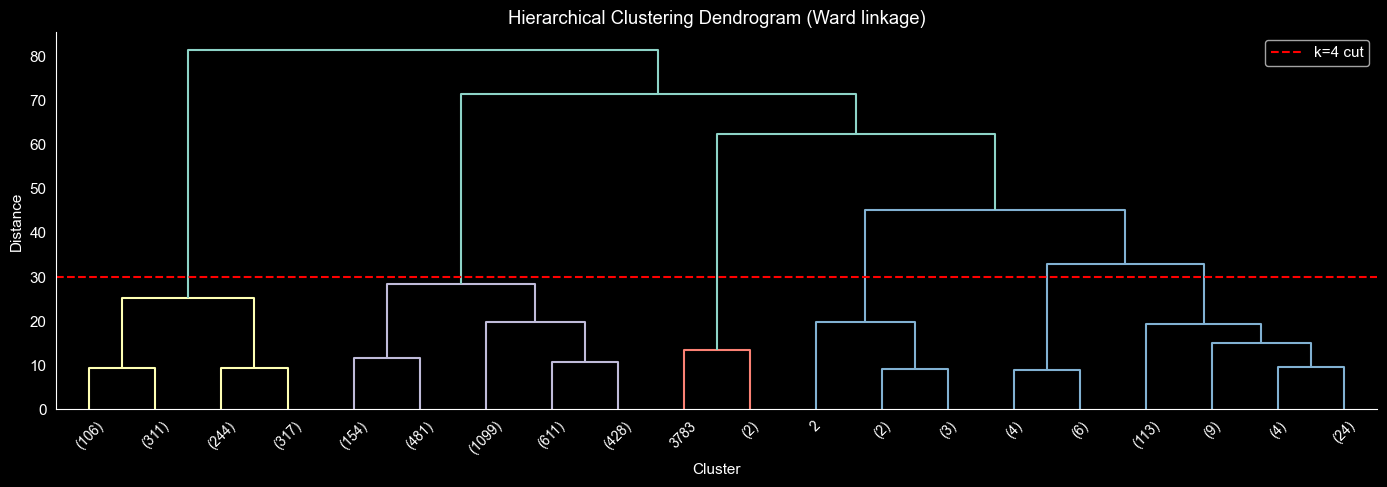

Hierarchical (k=4) -- Silhouette: 0.606 ; Davies-Bouldin: 0.653 ; Calinski-Harabasz: 2586
The dendrogram confirms the existence of four clusters of customers in line with the findings from the K-means output.


In [203]:
#  Hierarchical Clustering

# Dendrogram on the entire  dataset, this works due to the basket matrix being constructed as a sparse matrix.
Z = linkage(rfm_scaled, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=10,
           color_threshold=0.7*max(Z[:,2]))
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage)')
ax.set_xlabel('Cluster')
ax.set_ylabel('Distance')
ax.axhline(y=ax.get_ylim()[1]*0.35, ls='--', color='red', label='k=4 cut')
ax.legend()
ax.grid(False)
plt.tight_layout(); plt.show()

# Fit full hierarchical model
hc = AgglomerativeClustering(n_clusters=4)
rfm['HC_Cluster'] = hc.fit_predict(rfm_scaled)

sil_hc = silhouette_score(rfm_scaled, rfm['HC_Cluster'])
db_hc  = davies_bouldin_score(rfm_scaled, rfm['HC_Cluster'])
ch_hc  = calinski_harabasz_score(rfm_scaled, rfm['HC_Cluster'])

print(f'Hierarchical (k=4) -- Silhouette: {sil_hc:.3f} ; Davies-Bouldin: {db_hc:.3f} ; Calinski-Harabasz: {ch_hc:.0f}')
print("The dendrogram confirms the existence of four clusters of customers in line with the findings from the K-means output.")

In [204]:
# Side-by-side validation metric comparison
metrics = pd.DataFrame(
    {
        "Algorithm": [
            "K-Means (k=4)",
            "Hierarchical Ward (k=4)",
        ],
        "Silhouette (higher = better)": [
            round(sil_km, 3),
            round(sil_hc, 3),
        ],
        "Davies-Bouldin (lower = better)": [
            round(db_km, 3),
            round(db_hc, 3),
        ],
        "Calinski-Harabasz (higher = better)": [
            round(ch_km, 0),
            round(ch_hc, 0),
        ],
    }
)

print("=== Clustering Validation Metrics (k=4) ===")
print(metrics.to_string(index=False))
print("\nConclusion: K-Means outperforms Hierarchical Ward slightly on two out of the three internal metrics at k=4.")
print("Looking at the values, it can be said that either method can be used to perform clusterization and produce similar results.")


=== Clustering Validation Metrics (k=4) ===
              Algorithm  Silhouette (higher = better)  Davies-Bouldin (lower = better)  Calinski-Harabasz (higher = better)
          K-Means (k=4)                         0.595                            0.619                               2745.0
Hierarchical Ward (k=4)                         0.606                            0.653                               2586.0

Conclusion: K-Means outperforms Hierarchical Ward slightly on two out of the three internal metrics at k=4.
Looking at the values, it can be said that either method can be used to perform clusterization and produce similar results.


# 8. Classification (Decision Tree and Gaussian Naive Bayes) - Where the cluster labels are used for interpretability.

A shallow decision tree is useful because it produces readable IF-THEN rules, while Gaussian Naive Bayes provides a simpler probabilistic baseline.

In [205]:
# constructing a feature matrix which encodes labels.
X_clf = rfm[['Recency','Frequency','Monetary']].values
le    = LabelEncoder()
y_clf = le.fit_transform(rfm['Segment'])

print('Class distribution (classification target):')
for cls, nm in zip(range(len(le.classes_)), le.classes_):
    n = (y_clf == cls).sum()
    print(f'  {nm:25s}: {n:,} ({n/len(y_clf)*100:.1f}%)')

Class distribution (classification target):
  At-Risk / Lapsed         : 989 (25.2%)
  Champions                : 3 (0.1%)
  Loyal Regulars           : 52 (1.3%)
  New / Occasional         : 2,876 (73.4%)


In [206]:
#Constructing the decision tree. The max depth chosen here is 4 as a tree with higher depth would memorize noise which may lead to unactionable results.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt.fit(X_clf, y_clf)

cv_dt = cross_val_score(dt, X_clf, y_clf, cv=cv, scoring='f1_macro')
print(f'Decision Tree - 5-fold macro-F1: {cv_dt.mean():.3f} +/- {cv_dt.std():.3f}')
print(f'Training accuracy: {dt.score(X_clf, y_clf):.3f}')

# Feature importances
imp = pd.Series(dt.feature_importances_,
                 index=['Recency','Frequency','Monetary']).sort_values(ascending=False)
print('\nFeature importances:')
print(imp.round(3).to_string())


Decision Tree - 5-fold macro-F1: 0.842 +/- 0.057
Training accuracy: 0.974

Feature importances:
Monetary     0.368
Recency      0.331
Frequency    0.301


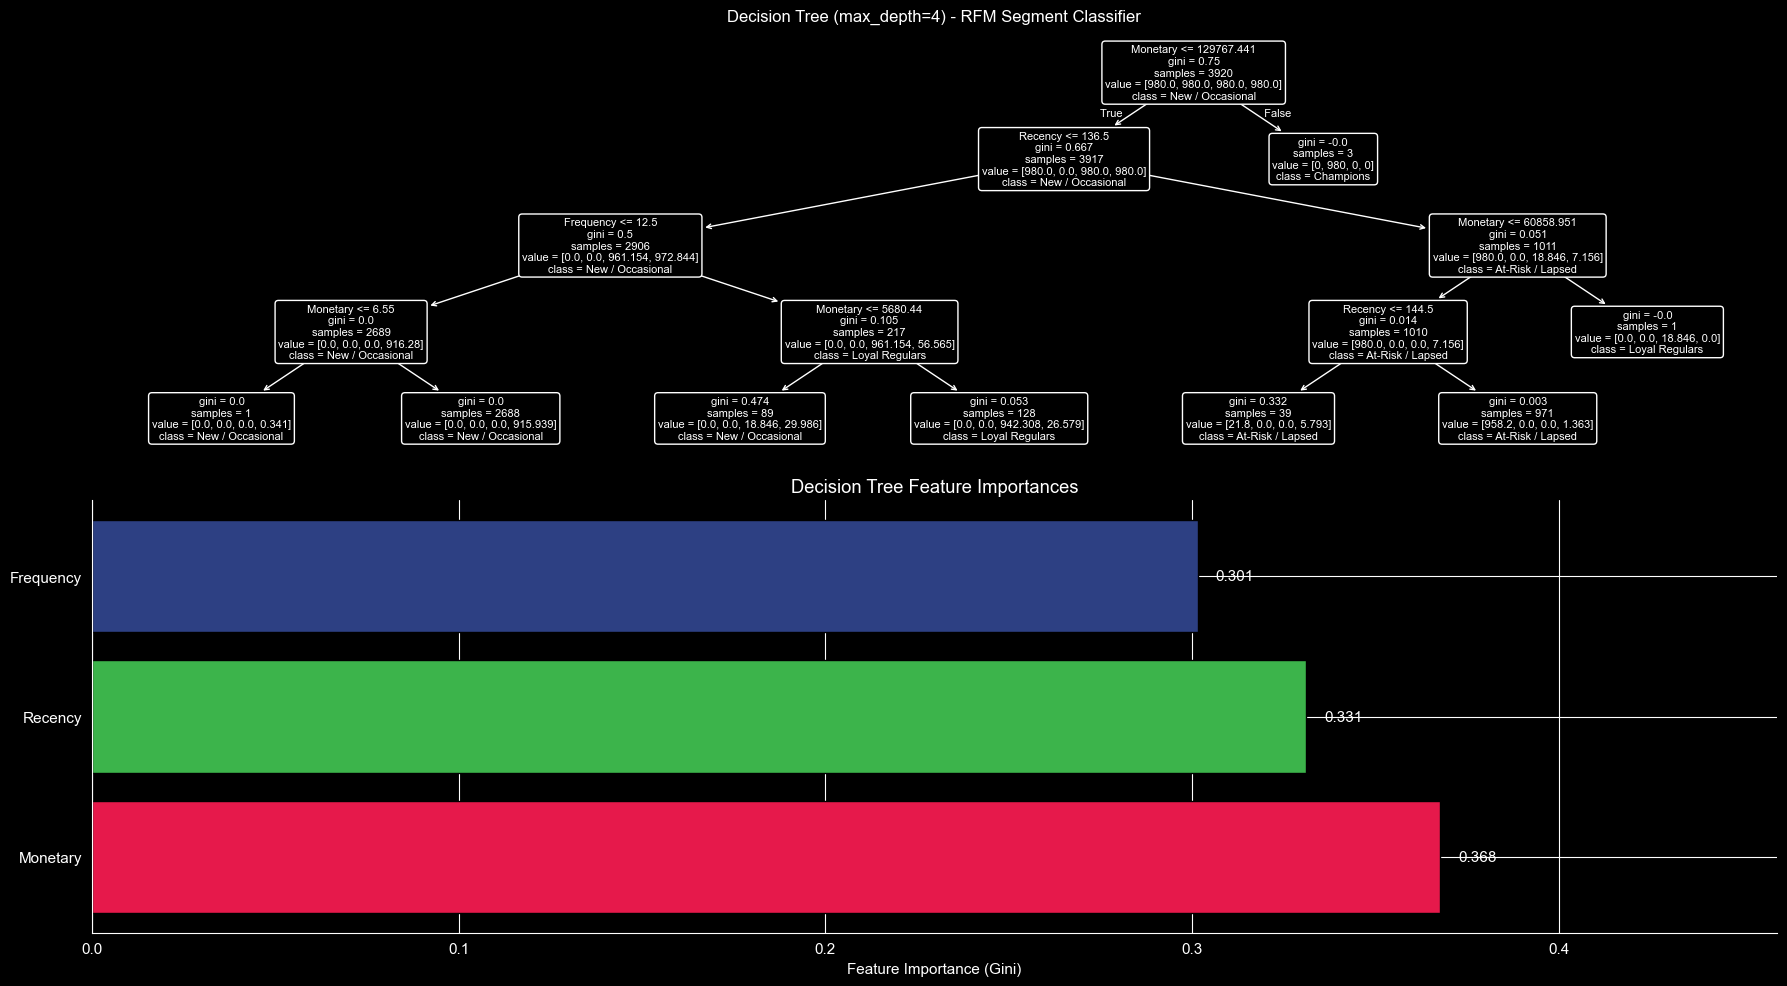

In [207]:
#Plotting the decision tree and feature importance bars.

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# top: tree diagram
plot_tree(dt,
          feature_names=['Recency','Frequency','Monetary'],
          class_names=le.classes_,
          filled=False, rounded=True, fontsize=8, ax=axes[0])
axes[0].set_title('Decision Tree (max_depth=4) - RFM Segment Classifier', fontsize=12)

# bottom: feature importance bar
axes[1].barh(imp.index, imp.values,
             color=['#e6194b','#3cb44b',"#2d4083"][:len(imp)], edgecolor='black')
axes[1].set_xlabel('Feature Importance (Gini)')
axes[1].set_title('Decision Tree Feature Importances')
axes[1].set_xlim(0, imp.max() * 1.25)
for i, v in enumerate(imp.values):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()


=== Decision Tree Classification Report ===
                  precision    recall  f1-score   support

At-Risk / Lapsed       0.98      1.00      0.99       989
       Champions       1.00      1.00      1.00         3
  Loyal Regulars       0.40      0.98      0.56        52
New / Occasional       1.00      0.97      0.98      2876

        accuracy                           0.97      3920
       macro avg       0.84      0.99      0.88      3920
    weighted avg       0.99      0.97      0.98      3920



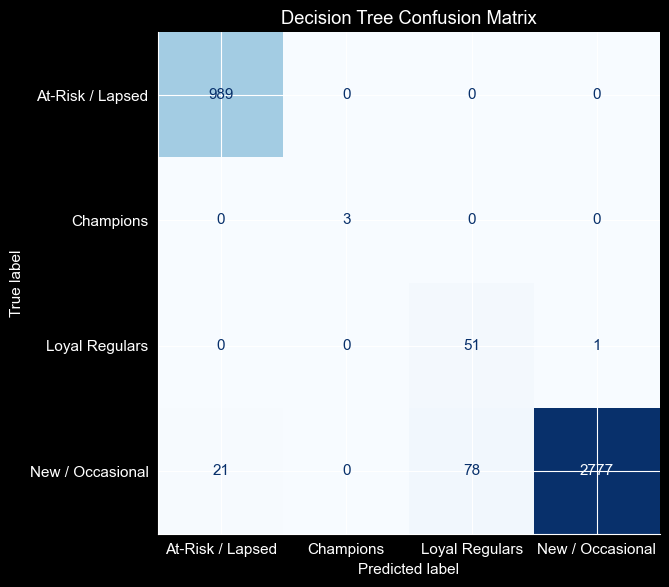

In [208]:
y_pred_dt = dt.predict(X_clf)

print('=== Decision Tree Classification Report ===')
print(classification_report(y_clf, y_pred_dt, target_names=le.classes_))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_clf, y_pred_dt,
    display_labels=le.classes_,
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title('Decision Tree Confusion Matrix')
plt.tight_layout()
plt.show()

In [209]:
# Gaussian Naive Bayes on the Recency, Frequency, and Monetary features.
gnb = GaussianNB()
gnb.fit(X_clf, y_clf)

cv_nb = cross_val_score(gnb, X_clf, y_clf, cv=cv, scoring='f1_macro')
print(f'Naive Bayes — 5-fold macro-F1: {cv_nb.mean():.3f} +/- {cv_nb.std():.3f}')

# Class priors
print('\nClass priors learned by Naive Bayes:')
for cls, prior in zip(le.classes_, gnb.class_prior_):
    print(f'  P({cls}) = {prior:.3f}')

# Per-class feature means
print('\nPer-class feature means (theta):')
theta_df = pd.DataFrame(gnb.theta_,
                         columns=['Recency','Frequency','Monetary'],
                         index=le.classes_).round(1)
print(theta_df.to_string())

Naive Bayes — 5-fold macro-F1: 0.749 +/- 0.095

Class priors learned by Naive Bayes:
  P(At-Risk / Lapsed) = 0.252
  P(Champions) = 0.001
  P(Loyal Regulars) = 0.013
  P(New / Occasional) = 0.734

Per-class feature means (theta):
                  Recency  Frequency  Monetary
At-Risk / Lapsed    244.6        1.6     526.7
Champions             3.3       36.0  207560.2
Loyal Regulars       12.2       43.8   31172.2
New / Occasional     41.4        4.4    1579.9


=== Naive Bayes Classification Report ===
                  precision    recall  f1-score   support

At-Risk / Lapsed       0.90      0.99      0.94       989
       Champions       1.00      1.00      1.00         3
  Loyal Regulars       0.41      1.00      0.58        52
New / Occasional       1.00      0.93      0.97      2876

        accuracy                           0.95      3920
       macro avg       0.82      0.98      0.87      3920
    weighted avg       0.96      0.95      0.95      3920



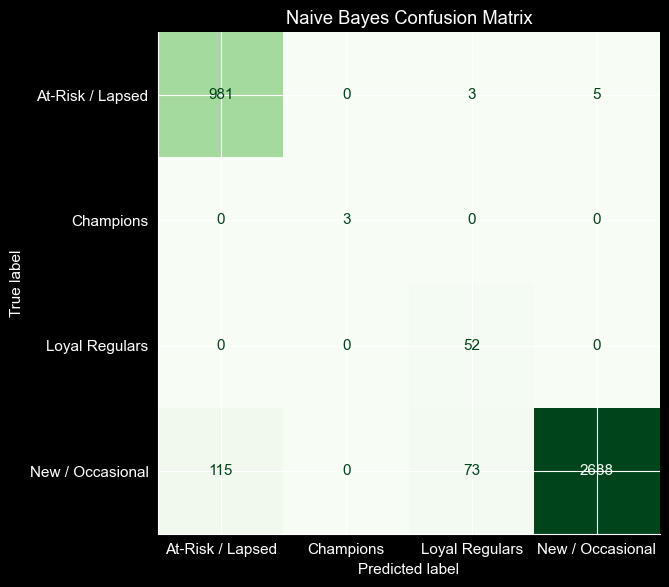

In [210]:
y_pred_nb = gnb.predict(X_clf)

print('=== Naive Bayes Classification Report ===')
print(classification_report(y_clf, y_pred_nb, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_clf, y_pred_nb,
    display_labels=le.classes_,
    cmap='Greens', ax=ax, colorbar=False
)
ax.set_title('Naive Bayes Confusion Matrix')
plt.tight_layout()
plt.show()

In [211]:
# Side-by-side classifier comparison
clf_comparison = pd.DataFrame({
    'Classifier':    ['Decision Tree (depth=4)', 'Gaussian Naive Bayes'],
    '5-fold macro-F1':     [f'{cv_dt.mean():.3f} +/- {cv_dt.std():.3f}',
                             f'{cv_nb.mean():.3f} +/- {cv_nb.std():.3f}'],
    'Training accuracy':  [f'{dt.score(X_clf, y_clf):.3f}',
                             f'{gnb.score(X_clf, y_clf):.3f}'],
    'Primary value':      ['Human-readable IF-THEN rules',
                            'Probabilistic feature-class associations'],
})
print('======================= Classifier Comparison ===========================')
print(clf_comparison.to_string(index=False))
print()
print('Both classifiers achieve high weighted macro-F1 (>0.90), confirming the K-Means')


======================= Classifier Comparison ===========================
             Classifier 5-fold macro-F1 Training accuracy                            Primary value
Decision Tree (depth=4) 0.842 +/- 0.057             0.974             Human-readable IF-THEN rules
   Gaussian Naive Bayes 0.749 +/- 0.095             0.950 Probabilistic feature-class associations

Both classifiers achieve high weighted macro-F1 (>0.90), confirming the K-Means


In [212]:
#  Quantifying At-Risk vs New/Occasional classification overlap
from sklearn.metrics import confusion_matrix
import numpy as np

target_names_sorted = le.classes_  # alphabetical order

def confusion_summary(y_true, y_pred, model_name):
    # Printing full confusion matrix and extract At-Risk/New-Occasional cross-confusion.
    print(f'\n{'='*60}')
    print(f'  {model_name} - Full Confusion Matrix')
    print(f'{'='*60}')
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=target_names_sorted, columns=target_names_sorted)
    cm_df.index.name = 'Actual'
    cm_df.columns.name = 'Predicted'
    print(cm_df.to_string())

    # Locating the two classes of interest
    classes = list(target_names_sorted)
    ar_idx  = next(i for i, c in enumerate(classes) if 'At-Risk' in c or 'At_Risk' in c or 'Lapsed' in c)
    no_idx  = next(i for i, c in enumerate(classes) if 'New' in c or 'Occasional' in c)

    ar_pred_as_no = cm[ar_idx, no_idx]   # actual At-Risk, predicted New/Occ
    no_pred_as_ar = cm[no_idx, ar_idx]   # actual New/Occ, predicted At-Risk
    ar_total  = cm[ar_idx].sum()
    no_total  = cm[no_idx].sum()

    print(f'\n  Cross-confusion summary:')
    print(f'    At-Risk customers mis-classified as New/Occasional : '
          f'{ar_pred_as_no:>4d} / {ar_total} ({ar_pred_as_no/ar_total*100:.1f}%)')
    print(f'    New/Occasional customers mis-classified as At-Risk  : '
          f'{no_pred_as_ar:>4d} / {no_total} ({no_pred_as_ar/no_total*100:.1f}%)')
    print()
    print(f'  Full classification report:')
    from sklearn.metrics import classification_report
    print(classification_report(y_true, y_pred, target_names=target_names_sorted, digits=3))


confusion_summary(y_clf, y_pred_dt, 'Decision Tree (depth=4)')
confusion_summary(y_clf, y_pred_nb, 'Gaussian Naive Bayes')

print('-'*60)


  Decision Tree (depth=4) - Full Confusion Matrix
Predicted         At-Risk / Lapsed  Champions  Loyal Regulars  New / Occasional
Actual                                                                         
At-Risk / Lapsed               989          0               0                 0
Champions                        0          3               0                 0
Loyal Regulars                   0          0              51                 1
New / Occasional                21          0              78              2777

  Cross-confusion summary:
    At-Risk customers mis-classified as New/Occasional :    0 / 989 (0.0%)
    New/Occasional customers mis-classified as At-Risk  :   21 / 2876 (0.7%)

  Full classification report:
                  precision    recall  f1-score   support

At-Risk / Lapsed      0.979     1.000     0.989       989
       Champions      1.000     1.000     1.000         3
  Loyal Regulars      0.395     0.981     0.564        52
New / Occasional      1.0

# 9. Anomaly Detection — DBSCAN and Local Outlier Factor

This section uses two different anomaly detectors to find unusual customer behavior in RFM space.

Using both DBSCAN and LOF is helpful because overlap between the methods strengthens confidence in the most extreme cases.

In [213]:
# Anomaly Detection — DBSCAN and LOF
dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
rfm['LOF_label'] = lof.fit_predict(rfm_scaled)
rfm['LOF_score'] = -lof.negative_outlier_factor_

n_dbscan_noise = (rfm['DBSCAN_Cluster'] == -1).sum()
n_lof_out = (rfm['LOF_label'] == -1).sum()

# Cross-validation: checking how many customers were flagged by algorithms
both_flagged = ((rfm['DBSCAN_Cluster'] == -1) & (rfm['LOF_label'] == -1)).sum()

print(f'DBSCAN noise points: {n_dbscan_noise} ({n_dbscan_noise / len(rfm) * 100:.1f}%)')
print(f'LOF anomalies:       {n_lof_out} ({n_lof_out / len(rfm) * 100:.1f}%)')
print(f'Flagged by both:     {both_flagged}')

anomalies = rfm[rfm['LOF_label'] == -1].sort_values('LOF_score', ascending=False)
print('\n=== Anomaly count by segment ===')
print(rfm.groupby('Segment')['LOF_label'].apply(lambda x: (x==-1).sum()))
print('\nTop ten (10) anomalous customers:')
anomalies[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'LOF_score', 'Segment']].head(10)

DBSCAN noise points: 52 (1.3%)
LOF anomalies:       196 (5.0%)
Flagged by both:     38

=== Anomaly count by segment ===
Segment
At-Risk / Lapsed    85
Champions            3
Loyal Regulars      23
New / Occasional    85
Name: LOF_label, dtype: int64

Top ten (10) anomalous customers:


,CustomerID,Recency,Frequency,Monetary,LOF_score,Segment
2820,16754,372,1,2002.40,6.433458,At-Risk / Lapsed
2,12748,1,209,33719.73,6.102733,Loyal Regulars
2307,16048,373,2,256.44,5.293406,At-Risk / Lapsed
3783,18102,1,60,259657.30,4.969851,Champions
1413,14813,370,2,155.43,4.292114,At-Risk / Lapsed
3598,17850,372,34,5391.21,4.034240,At-Risk / Lapsed
107,12967,358,2,1660.90,3.967778,At-Risk / Lapsed
2598,16446,1,2,168472.50,3.852541,Champions
3314,17450,8,46,194550.79,3.579474,Champions
1607,15098,182,3,39916.50,3.490667,At-Risk / Lapsed


In [214]:
# What the top anomalous customers bought.
top_ids = anomalies['CustomerID'].head(5).tolist()
print('Top transactions for most anomalous customers:')
(
    df_cust[df_cust['CustomerID'].isin(top_ids)]
    .sort_values('TotalPrice', ascending=False)
    [['CustomerID','InvoiceNo','InvoiceDate','Description','Quantity','UnitPrice','TotalPrice']]
    .head(15)
)

Top transactions for most anomalous customers:


,CustomerID,InvoiceNo,InvoiceDate,Description,Quantity,UnitPrice,TotalPrice
16438,18102,537659,2010-12-07 16:43:00,VINTAGE UNION JACK MEMOBOARD,600,6.38,3828.00
411231,18102,572209,2011-10-21 12:08:00,LANDMARK FRAME NOTTING HILL,300,10.95,3285.00
411230,18102,572209,2011-10-21 12:08:00,LANDMARK FRAME OXFORD STREET,300,10.95,3285.00
411229,18102,572209,2011-10-21 12:08:00,LANDMARK FRAME COVENT GARDEN,300,10.95,3285.00
411232,18102,572209,2011-10-21 12:08:00,LANDMARK FRAME LONDON BRIDGE,300,10.95,3285.00
411235,18102,572209,2011-10-21 12:08:00,LANDMARK FRAME BAKER STREET,300,10.95,3285.00
411234,18102,572209,2011-10-21 12:08:00,LANDMARK FRAME CAMDEN TOWN,300,10.95,3285.00
84319,18102,543378,2011-02-07 15:34:00,VINTAGE UNION JACK MEMOBOARD,504,6.38,3215.52
84323,18102,543379,2011-02-07 15:37:00,VINTAGE UNION JACK MEMOBOARD,504,6.38,3215.52
540061,18102,581457,2011-12-08 18:43:00,WALL ART KEEP CALM,698,4.15,2896.70


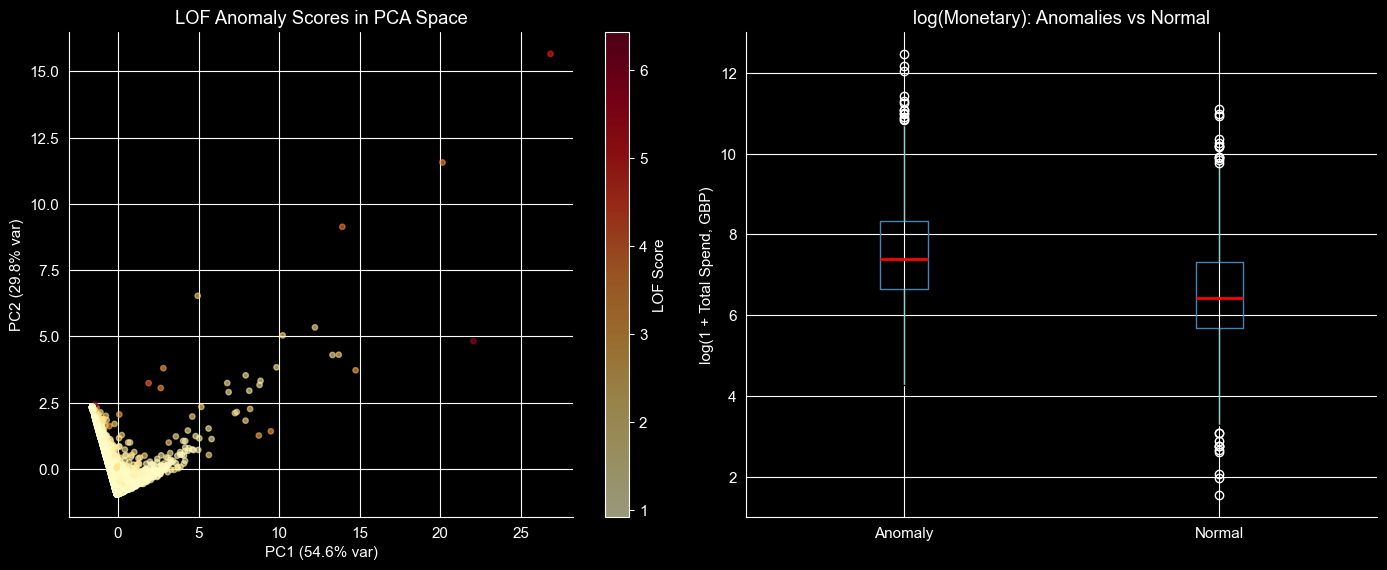

In [215]:
pca2 = PCA(n_components=2, random_state=42)
pca_coords = pca2.fit_transform(rfm_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: LOF scores in PCA space
sc = axes[0].scatter(pca_coords[:,0], pca_coords[:,1],
                     c=rfm['LOF_score'], cmap='YlOrRd', alpha=0.6, s=15)
plt.colorbar(sc, ax=axes[0], label='LOF Score')
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].set_title('LOF Anomaly Scores in PCA Space')

# Right: Monetary boxplot — anomalies vs normal
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])
rfm['Status'] = rfm['LOF_label'].map({1:'Normal', -1:'Anomaly'})
rfm.boxplot(column='Monetary_log', by='Status', ax=axes[1],
            boxprops=dict(color='steelblue'),
            medianprops=dict(color='red', linewidth=2))
axes[1].set_title('log(Monetary): Anomalies vs Normal')
axes[1].set_xlabel(''); axes[1].set_ylabel('log(1 + Total Spend, GBP)')
plt.suptitle('')
plt.tight_layout(); plt.show()

# 9. PCA visualization by customer segment.
* To make the RFM segmentation easier to interpret, the standardized Recency, Frequency, and Monetary features are projected into two principal components
* This plot shows whether the business-oriented segment labels found by K-Means remain visually separable in a lower-dimensional view, while also highlighting customers flagged by DBSCAN as noise. Reporting the explained variance and component loadings helps connect the visual clusters back to the original RFM variables.

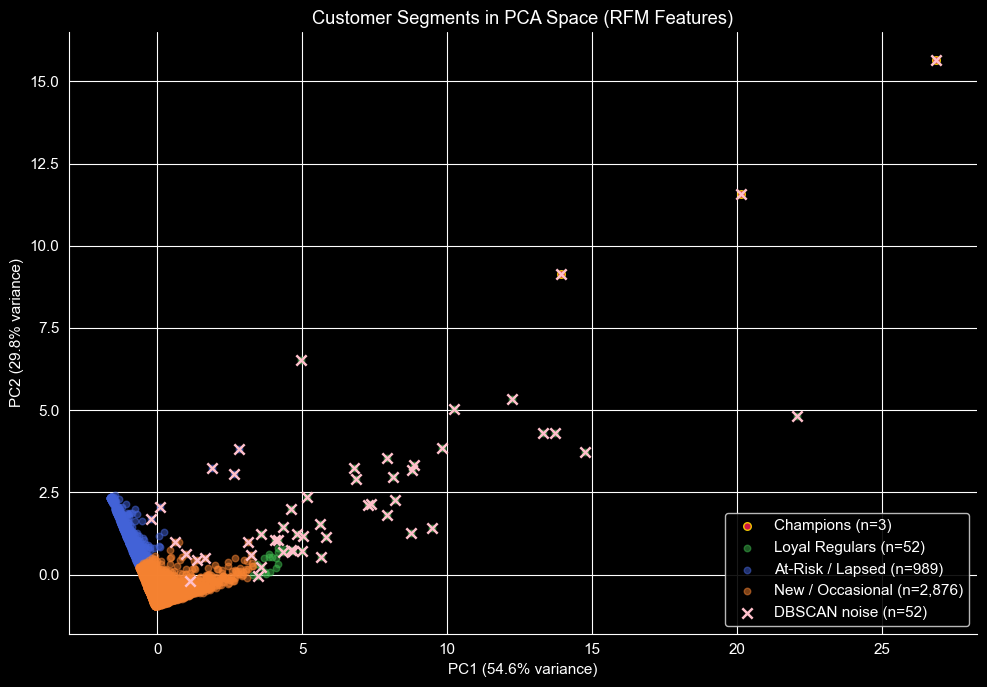

PC1 + PC2 total variance: 84.4%
Component loadings:
             PC1    PC2
Recency   -0.413  0.884
Frequency  0.670  0.131
Monetary   0.618  0.448


In [216]:
#Plotting the pca distribution of the customer segments based on their RFM profiles.
pca_df = pd.DataFrame(pca_coords, columns=['PC1','PC2'])
pca_df['Segment']      = rfm['Segment'].values
pca_df['DBSCAN_noise'] = (rfm['DBSCAN_Cluster'] == -1).values

palette = {'Champions':'#e6194b','Loyal Regulars':'#3cb44b',
           'At-Risk / Lapsed':'#4363d8','New / Occasional':'#f58231'}

fig, ax = plt.subplots(figsize=(10, 7))
for seg, color in palette.items():
    m = pca_df['Segment'] == seg

    if seg == 'Champions':
        ax.scatter(pca_df.loc[m,'PC1'], pca_df.loc[m,'PC2'],
               label=f'{seg} (n={m.sum():,})', color=color,edgecolors ='#ffd700', alpha=0.9, s=30)
    else:
        ax.scatter(pca_df.loc[m,'PC1'], pca_df.loc[m,'PC2'],
               label=f'{seg} (n={m.sum():,})', color=color, alpha=0.5, s=22)

m_noise = pca_df['DBSCAN_noise']
ax.scatter(pca_df.loc[m_noise,'PC1'], pca_df.loc[m_noise,'PC2'],
           marker='x', color='pink', s=55, linewidths=1.8,
           label=f'DBSCAN noise (n={m_noise.sum()})', zorder=5)

ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Customer Segments in PCA Space (RFM Features)')
ax.legend(loc='lower right', framealpha=0.9)
plt.tight_layout(); plt.show()

print(f'PC1 + PC2 total variance: {pca2.explained_variance_ratio_.sum()*100:.1f}%')
loadings = pd.DataFrame(pca2.components_.T, columns=['PC1','PC2'],
                         index=['Recency','Frequency','Monetary'])
print('Component loadings:')
print(loadings.round(3))

# 10. Seasonal Analysis

Transactions are mapped to seasons and cross-tabulated with customer segments to
answer Discovery Question 3: *What distinct purchasing patterns emerge among segments by season?*

In [217]:
season_map = {12:'Winter',1:'Winter',2:'Winter',
              3:'Spring', 4:'Spring', 5:'Spring',
              6:'Summer', 7:'Summer', 8:'Summer',
              9:'Autumn',10:'Autumn',11:'Autumn'}

df_seg = df_cust.merge(rfm[['CustomerID','Segment']], on='CustomerID', how='left')
df_seg['Season'] = df_seg['Month'].map(season_map)

season_order = ['Winter','Spring','Summer','Autumn']

# Revenue by season × segment
rev_season = (df_seg.groupby(['Season','Segment'])['TotalPrice']
              .sum().unstack(fill_value=0)
              .loc[season_order])

# Invoice count by season × segment
inv_season = (df_seg.groupby(['Season','Segment'])['InvoiceNo']
              .nunique().unstack(fill_value=0)
              .loc[season_order])

print('=== Revenue by Season * Segment (GBP) ===')
print(rev_season.round(0).to_string())
print('\n=== Invoice Count by Season * Segment ===')
print(inv_season.to_string())

=== Revenue by Season * Segment (GBP) ===
Segment  At-Risk / Lapsed  Champions  Loyal Regulars  New / Occasional
Season                                                                
Winter           194995.0   240537.0        433785.0          899576.0
Spring           210935.0    61386.0        308070.0          847935.0
Summer           115011.0    95905.0        361128.0          936937.0
Autumn                0.0   224853.0        517973.0         1859367.0

=== Invoice Count by Season * Segment ===
Segment  At-Risk / Lapsed  Champions  Loyal Regulars  New / Occasional
Season                                                                
Winter                608         16             571              2572
Spring                651         19             558              2410
Summer                315         19             531              2717
Autumn                  0         54             617              4988


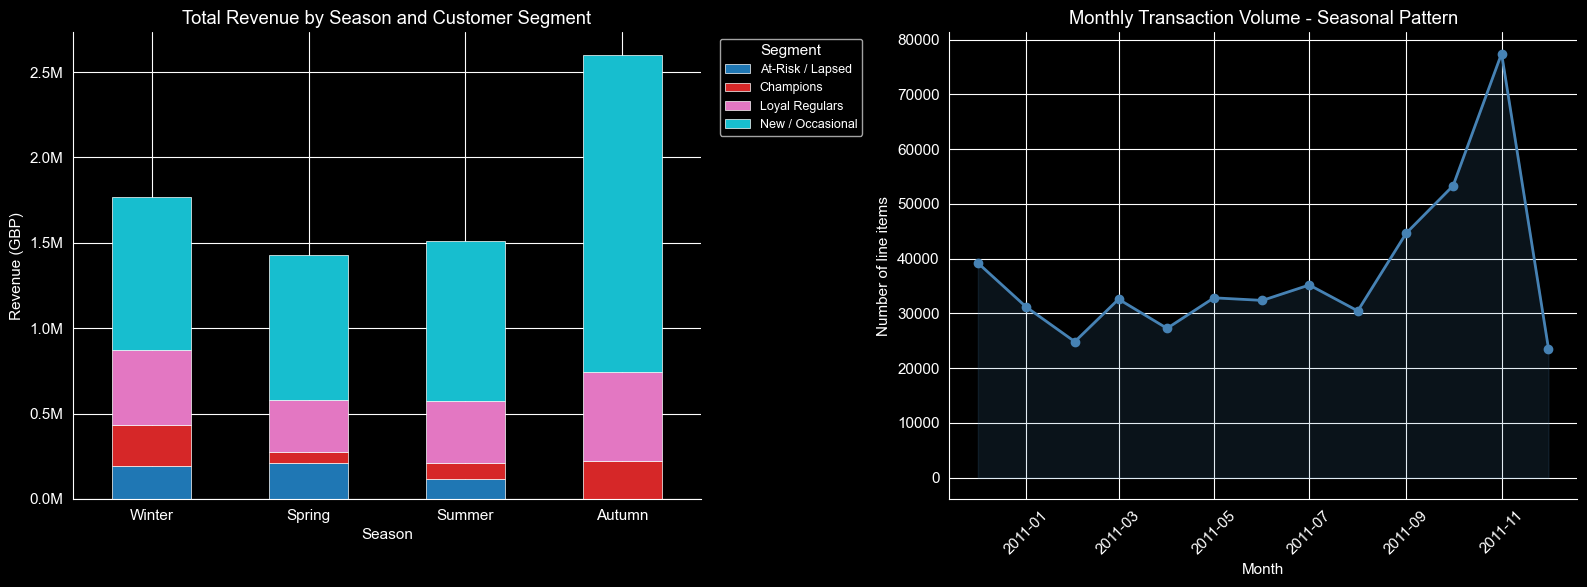

In [218]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar showing revenue by season
rev_season.plot(kind='bar', stacked=True, ax=axes[0],
                colormap='tab10', edgecolor='white', linewidth=0.5)
axes[0].set_title('Total Revenue by Season and Customer Segment')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Revenue (GBP)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Monthly transaction volume with seasonal shading
monthly = (df[['InvoiceMonth','InvoiceNo']]
           .groupby('InvoiceMonth')['InvoiceNo'].count())
monthly.index = monthly.index.to_timestamp()

axes[1].plot(monthly.index, monthly.values, 'o-', color='steelblue', linewidth=2)
axes[1].fill_between(monthly.index, monthly.values, alpha=0.15, color='steelblue')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of line items')
axes[1].set_title('Monthly Transaction Volume - Seasonal Pattern')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

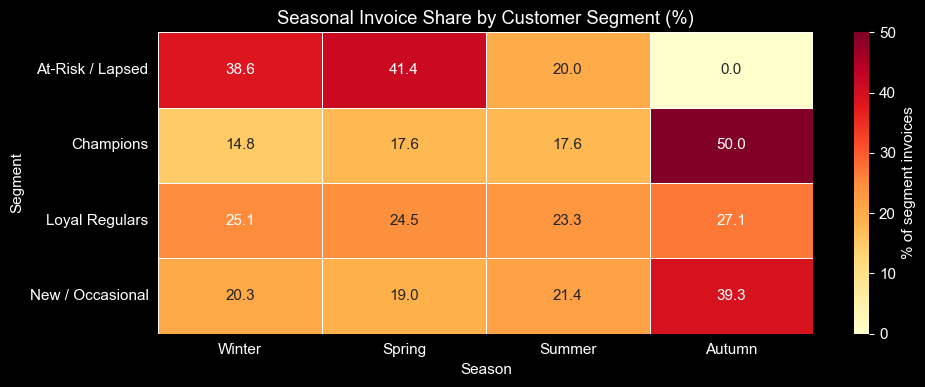


Key observation: All segments show Autumn peak (Oct-Nov pre-Christmas ordering).
In the Autumn season there a no At-risk/Lapsed customers, where as a high number of them occur in the winter and spring seasons.


In [219]:
# Heatmap: normalized invoice share by season for each segment.
# counting the percentage of invoices of a particular segment in each season.
inv_norm = inv_season.div(inv_season.sum(axis=0), axis=1) * 100  # % share per segment

plt.figure(figsize=(10, 4))
sns.heatmap(inv_norm.T, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': '% of segment invoices'})
plt.title('Seasonal Invoice Share by Customer Segment (%)')
plt.xlabel('Season'); plt.ylabel('Segment')
plt.tight_layout(); plt.show()

print('\nKey observation: All segments show Autumn peak (Oct-Nov pre-Christmas ordering).')
print('In the Autumn season there a no At-risk/Lapsed customers, where as a high number of them occur in the winter and spring seasons.')